In [2]:
import numpy as np
from pricing.BSMgreeks import CallDelta, CallOption, Greeks_1_par
import matplotlib.pyplot as plt
from pricing.PriceSim import stock_full_GBM, stock_full_jump_diff
from pricing.OptionsPrice import FourierPricing, F_call_price_Lewis, char_BSM, char_Jump


In [3]:
import importlib
import pricing.PriceSim

importlib.reload(pricing.PriceSim)

print(dir(pricing.PriceSim))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'np', 'plt', 'rng', 'stock_1_step', 'stock_full_GBM', 'stock_full_jump_diff']


### Volatility-Delta hedging with brownian motion; hedging with implied and actual volatility
Literature: Paul Wilmott on Quantitative Finance, Paul Wilmott. Chapter 12, Chapter 57

Our goal here is to extend the discussion of this chapter to jump processes. We begin by first coding the math presented in the book, then connecting it to the jump process extension for this BSM model.




In [ ]:
### Delta hedging of a call option:

#Strategy:
# We sell a call option and hedge the position by buying delta shares of the underlying stock. The PnL of the hedged position is given by:

#We define a class as we want to keep most parameters the same for by-testing, while changing 
# volatility used in the delta, the method used for calculating the price of a call, or changing the
# simulation situation.
class VolatilityHedge:
    def __init__(self, S0, K, T, r, D, sigma_a, sigma_i, N, stock_sim, F_method=False, mu_J=None, delta_J=None, lambd=None):
        '''
        S0: initial stock price
        K: strike price
        T: time to maturity
        r: risk-free interest rate
        D: dividend yield
        sigma_a: realised volatility of the stock
        sigma_i: implied volatility of the option
        N: number of time steps
        mu_J: mean log jump size
        delta_J: variability of jump size
        lambd: jump intensity
        stock_sim: type of simulation to run for stock price generation
        F_method (Boolean): whether to use Fourier method for option pricing
        mu_J: mean log jump size
        delta_J: variability of jump size
        lambd: jump intensity
        '''
        self.S0 = S0
        self.K = K
        self.T = T
        self.r = r
        self.D = D
        self.sigma_a = sigma_a
        self.sigma_i = sigma_i
        self.N = N
        self.stock_sim = stock_sim
        self.F_method = F_method
        self.mu_J = mu_J
        self.delta_J = delta_J
        self.lambd = lambd

    def hedge_simulation(self, sigma_hedge, call_option, call_delta, char_func=None, S_old = None):
        '''
        sigma_hedge: volatility used to compute delta
        call_option: function to compute the call option price
        call_delta: function to compute the delta of the call option
        char_func: characteristic function in fourier approach
        S_old: price array if you want to use a specific one instead of regenerating.
        '''
        ## Lists
        dt = self.T/self.N
        t = np.linspace(0, self.T, self.N+1)
        PnL = np.zeros(self.N+1)


        ## Option Price adjustment
        # If we use a fourier method, we create a function that takes the jump diffusion
        # parameters directly as given when the class is initialised. Thus enabling us to
        # minimize the amount of parameters .hedge_simulation needs. We thus include fourier
        # methods without being invasive to simpler methods of pricing.
        if self.F_method == True:
            call_option_class = FourierPricing(call_option, char_func, self.mu_J, self.delta_J, self.lambd).price
        else:
            call_option_class = call_option

        
        # Different price simulations have different arguments. If we wish to compare hedging strategies on the same stock price changes we can pick S_old instead. 
        if S_old is not None:
            S = S_old
        elif self.mu_J != None:
            S = self.stock_sim(self.S0, self.r, self.D, self.sigma_a, dt, self.T, self.lambd, self.mu_J, self.delta_J)
        else:
            S = self.stock_sim(self.S0, self.r, self.D, self.sigma_a, dt, self.T)


        call_price_temp = call_option_class(S[0], self.sigma_i, self.D, self.r, self.K, self.T)

        for j in range(self.N):
            call_price = call_option_class(S[j+1], self.sigma_i, self.D, self.r, self.K, self.T - t[j+1])

            dV = call_price - call_price_temp
            delta = call_delta(S[j], sigma_hedge, self.D, self.r, self.K, self.T - t[j])

            gain = delta * (S[j+1] - S[j]) - dV +  delta * self.D * S[j] * dt
            PnL[j+1] = PnL[j] + gain

            call_price_temp = call_price
    
        return PnL, S, t



#### Examples Of Use

In [5]:
#Creating our hedge simulation:


#Params
S0 = 100
K = 110
T = 1
r = 0.05
D = 0.0
sigma_a = 0.20
sigma_i = 0.30
N = 252

lambd = 2.0       # jump intensity
mu_J = -0.10     # mean log jump size
delta_J = 0.20    # volatility of log jump size



BSM_Hedge = VolatilityHedge(S0, K, T, r, D, sigma_a, sigma_i, N, stock_full_GBM)

#Number of simulations to run
n_simulations = 20


c:\Users\nikit\Projects\tr_al\strategies\pricing\BSMgreeks.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  return x_num/x_den


Mean PnL for hedging with actual volatility over 20 simulations:  5.776121851686722
Std PnL for hedging with actual volatility over 20 simulations:  1.1489181724777588


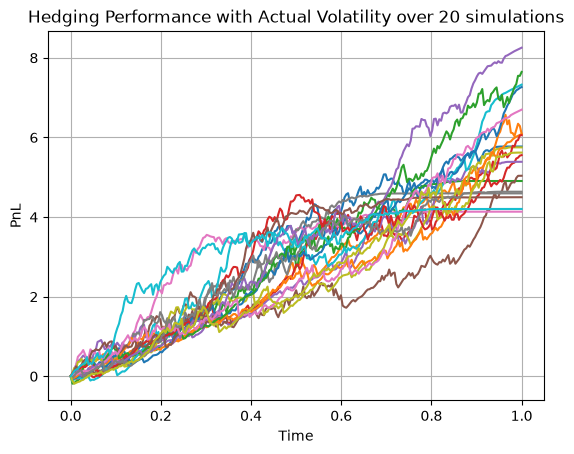

Mean PnL for hedging with implied volatility over 20 simulations:  6.045563738766462
Std PnL for hedging with implied volatility over 20 simulations:  2.034177940779151


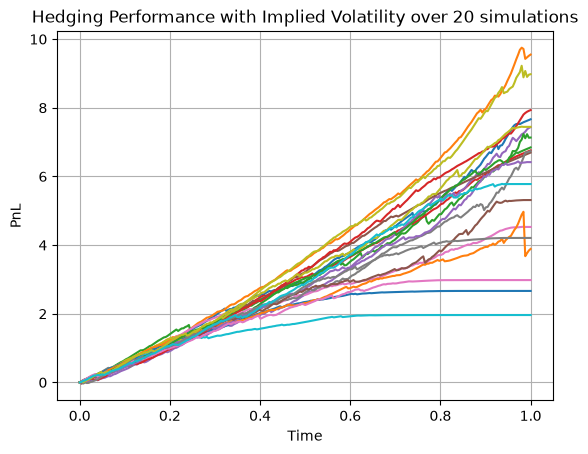

In [6]:
### Examples

# Hedging with actual volatility

plt.figure()
#Simulation parameters
final_pnl1 = np.zeros(n_simulations)
    
for j in range(n_simulations):
    pnl1, S1, t1 = BSM_Hedge.hedge_simulation(sigma_a, CallOption, CallDelta)
    plt.plot(t1, pnl1)
    final_pnl1[j] = pnl1[-1]

mean_pnl1 = np.mean(final_pnl1)
std_pnl1 = np.std(final_pnl1)
print(f"Mean PnL for hedging with actual volatility over {n_simulations} simulations: ", mean_pnl1)
print(f"Std PnL for hedging with actual volatility over {n_simulations} simulations: ", std_pnl1)
plt.xlabel('Time')
plt.ylabel('PnL')
plt.title(f"Hedging Performance with Actual Volatility over {n_simulations} simulations")
plt.grid()
plt.show()



# Hedging with implied volatility

#same params as above

plt.figure()
#Simulation parameters
final_pnl2 = np.zeros(n_simulations)


for j in range(n_simulations):
    pnl2, S2, t2 = BSM_Hedge.hedge_simulation(sigma_i, CallOption, CallDelta)
    plt.plot(t2, pnl2)
    final_pnl2[j] = pnl2[-1]

mean_pnl2 = np.mean(final_pnl2)
std_pnl2 = np.std(final_pnl2)
print(f"Mean PnL for hedging with implied volatility over {n_simulations} simulations: ", mean_pnl2)
print(f"Std PnL for hedging with implied volatility over {n_simulations} simulations: ", std_pnl2)
plt.xlabel('Time')
plt.ylabel('PnL')
plt.title(f"Hedging Performance with Implied Volatility over {n_simulations} simulations")
plt.grid()
plt.show()


We now move onto the jump-diffusion model from Merton (1976). In the below example we see that the standard call price and delta calculation are inaccurate. Only when jumps are avoided, do we have our previous results. This is indicative that jumps in market prices can strongly misvalue investments in stocks if using BSM.

Mean PnL for hedging with actual volatility over 1 simulations: BSM:  3.4874670911953682 Jump_Diff 8.206369161049524
Std PnL for hedging with actual volatility over 1 simulations: BSM:  0.0 Jump_Diff 0.0


C:\Users\nikit\AppData\Local\Temp\ipykernel_2080\412775321.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


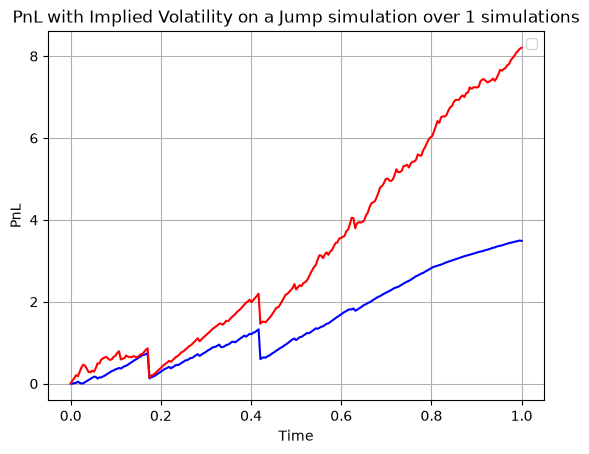

In [ ]:
n_simulations_jump = 1

Hedge_fourier = VolatilityHedge(S0, K, T, r, D, sigma_a, sigma_i, N, stock_full_jump_diff, F_method=True, mu_J = mu_J, delta_J = delta_J, lambd = lambd)




plt.figure()
#Simulation parameters
final_pnl3 = np.zeros(n_simulations_jump)
final_Jpnl3 = np.zeros(n_simulations_jump)
    
for j in range(n_simulations_jump):
    pnl3, S3, t3 = Hedge_fourier.hedge_simulation(sigma_i, F_call_price_Lewis, CallDelta, char_BSM)
    Jpnl3, S3, t3 = Hedge_fourier.hedge_simulation(sigma_i, F_call_price_Lewis, CallDelta, char_Jump, S3)
    plt.plot(t3, pnl3, color = 'blue', alpha = (1+j)/n_simulations_jump)
    plt.plot(t3, Jpnl3, color = 'red', alpha = (1+j)/n_simulations_jump)
    final_pnl3[j] = pnl3[-1]
    final_Jpnl3[j] = Jpnl3[-1]

mean_pnl3 = np.mean(final_pnl3)
std_pnl3 = np.std(final_pnl3)
mean_Jpnl3 = np.mean(final_Jpnl3)
std_Jpnl3 = np.std(final_Jpnl3)
print(f"Mean PnL for hedging with actual volatility over {n_simulations_jump} simulations: BSM: ", mean_pnl3, "Jump_Diff", mean_Jpnl3)
print(f"Std PnL for hedging with actual volatility over {n_simulations_jump} simulations: BSM: ", std_pnl3, "Jump_Diff", std_Jpnl3)
plt.xlabel('Time')
plt.ylabel('PnL')
plt.title(f"PnL with Implied Volatility on a Jump simulation over {n_simulations_jump} simulations")
plt.legend()
plt.grid()
plt.show()

